# Практическое задание № 1. Классификация


**Работу выполнил:**

Сухов Николай Михайлович, id: 368876

# Распознавание активности человека на основе данных с мобильных сенсоров

Необходимо по данным с мобильных сенсоров при помощи прикладных алгоритмов машинного обучения предсказать активность человека по шести классам движений:
* Движется по прямой
* Движется вверх (например, движение по лестнице вверх)
* Движется вниз (например, движение по лестнице вниз)
* Сидит
* Стоит
* Лежит

## Сведения о наборе данных
Набор данных содержит записи датчиков со сматфонов (акселерометр и гироскоп с частотой дискретизации 50 Гц) от 30 участников, выполняющих следующие действия: ходьба, ходьба по лестнице, ходьба по лестнице, сидение, стояние и лежание. Данные были предварительно обработаны при помощи фильтров шума. Набор данных представлен Хорхе Л. Рейес-Ортисом.

Признаки были извлечены из 3-х осевых необработанных сигналов акселерометра и гироскопа tAcc-XYZ и tGyro-XYZ. Эти сигналы были сняты с постоянной частотой 50 Гц. Затем были отфильтрованны с помощью медианного фильтра и низкочастотного фильтра Баттерворта 3-го порядка с частотой 20 Гц для удаления шумов. Аналогичным образом сигнал ускорения был разделен на сигналы ускорения тела и гравитации (`tBodyAcc-XYZ` и `tGravityAcc-XYZ`) с помощью другого низкочастотного фильтра Баттерворта с угловой частотой 0,3 Гц. Линейное ускорение тела и угловая скорость были использованы для получения сигналов "рывка" — (`tBodyAccJerk-XYZ` и `tBodyGyroJerk-XYZ`). Также величина этих трехмерных сигналов была расчитана с использованием евклидовой нормы — (`tBodyAccMag`, `tGravityAccMag`, `tBodyAccJerkMag`, `tBodyGyroMag`, `tBodyGyroJerkMag`). 

Наконец, к некоторым из этих сигналов было применено быстрое преобразование Фурье (БПФ), в результате чего получились `fBodyAcc-XYZ`, `fBodyAccJerk-XYZ`, `fBodyGyro-XYZ`, `fBodyAccJerkMag`, `fBodyGyroMag`, `fBodyGyroJerkMag`. (Обратите внимание на "f" для обозначения сигналов в частотной области). 

Набор переменных, которые были оценены по этим сигналам, следующий: 
* mean(): Среднее значение
* std(): Стандартное отклонение
* mad(): Среднее абсолютное отклонение 
* max(): Наибольшее значение в массиве
* min(): Наименьшее значение в массиве
* sma(): Область величины сигнала
* energy(): Мера энергии. Сумма квадратов, деленная на количество значений. 
* iqr(): Интерквартильный размах 
* entropy(): Энтропия сигнала
* arCoeff(): Коэффициенты авторегрессии с порядком Burg, равным 4
* correlation(): коэффициент корреляции между двумя сигналами
* maxInds(): индекс частотной составляющей с наибольшей величиной
* meanFreq(): средневзвешенное значение частотных компонент для получения средней частоты
* skewness(): перекос сигнала в частотной области 
* kurtosis(): эксцесс сигнала в частотной области 
* bandsEnergy(): Энергия частотного интервала в пределах 64 бинов БПФ каждого окна.
* angle(): Угол между векторами.
## Импорт библиотек
Первым делом импортируем необходимые библиотеки для работы с данными:

In [1]:
import os
import numpy as np
import pandas as pd

## Считываем набор данных

В прикладных задачах машинного обучения очень важен процесс извлечения признаков (feature extraction), в ходе которого данные интерпретируются в информативные признаки. Также этот процесс может называться проектирование признаков (feature engineering), это весьма трудоемкая и творческая задача. В рамках работы мы опустим эту часть и воспользуемся предобработанными данными. 

In [4]:
df = pd.read_csv('train.csv')
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


Теперь, загрузим полный набор данных и сохранить его под следующими четырьмя переменными:

* `train_X`: признаки, используемые для обучения модели
* `train_y`: метки, используемые для обучения модели
* `test_X`: признаки, используемые для проверки модели
* `test_y`: метки, используемые для проверки модели

In [5]:
def load_dataset(label_dict):
    train_X = pd.read_csv('train.csv').values[:,:-2]
    train_y = pd.read_csv('train.csv')['Activity']
    train_y = train_y.map(label_dict).values
    test_X = pd.read_csv('test.csv').values[:,:-2]
    test_y = pd.read_csv('test.csv')
    test_y = test_y['Activity'].map(label_dict).values
    return(train_X, train_y, test_X, test_y)
label_dict = {'WALKING':0, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':2, 'SITTING':3, 'STANDING':4, 'LAYING':5}
train_X, train_y, test_X, test_y = load_dataset(label_dict)

## Выбор модели

Импортируйте выбранную вами модель из библиотеки `sklearn` и инициализируйте её в объект `model`:

Также необходимо выбрать **несколько** моделей ML для сравнения полученных результатов.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

Для начала нормализуем наши данные:

In [ ]:
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

Размер train выборки: (7352, 561)
Размер test выборки: (2947, 561)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [13]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}
results = {}
target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

for name, model in models.items():
    print(f"{name}:")
    model.fit(train_X, train_y)
    yhat = model.predict(test_X)
    accuracy = accuracy_score(test_y, yhat)
    results[name] = accuracy
    
    print(f"Точность предсказаний: {accuracy:.4f}")
    print("\nДанные классификации:")
    print(classification_report(test_y, yhat, target_names=target_names))


Random Forest:
Точность предсказаний: 0.9260

Данные классификации:
                    precision    recall  f1-score   support

           Walking       0.89      0.96      0.92       496
  Walking Upstairs       0.89      0.90      0.90       471
Walking Downstairs       0.97      0.86      0.91       420
           Sitting       0.91      0.89      0.90       491
          Standing       0.90      0.92      0.91       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947

SVM:
Точность предсказаний: 0.9522

Данные классификации:
                    precision    recall  f1-score   support

           Walking       0.96      0.97      0.97       496
  Walking Upstairs       0.93      0.97      0.95       471
Walking Downstairs       0.98      0.92      0.95       420
           Sitting       0.94 

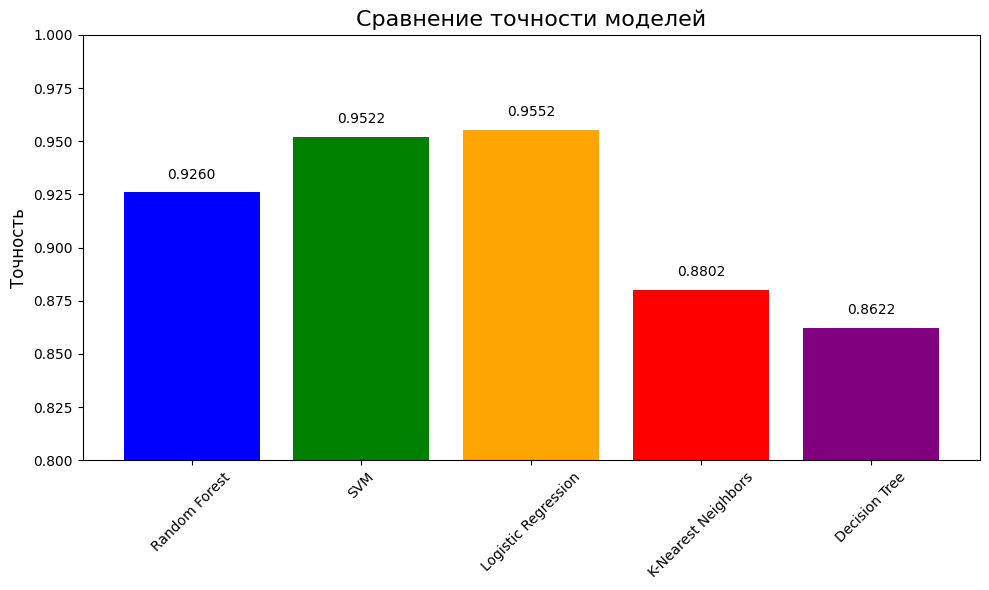

In [ ]:
plt.figure(figsize=(10, 6))
models_names = list(results.keys())
accuracies = list(results.values())

bars = plt.bar(models_names, accuracies, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.title('Сравнение точности моделей', fontsize=16)
plt.ylabel('Точность', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)

# Добавление значений на столбцы
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{accuracy:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


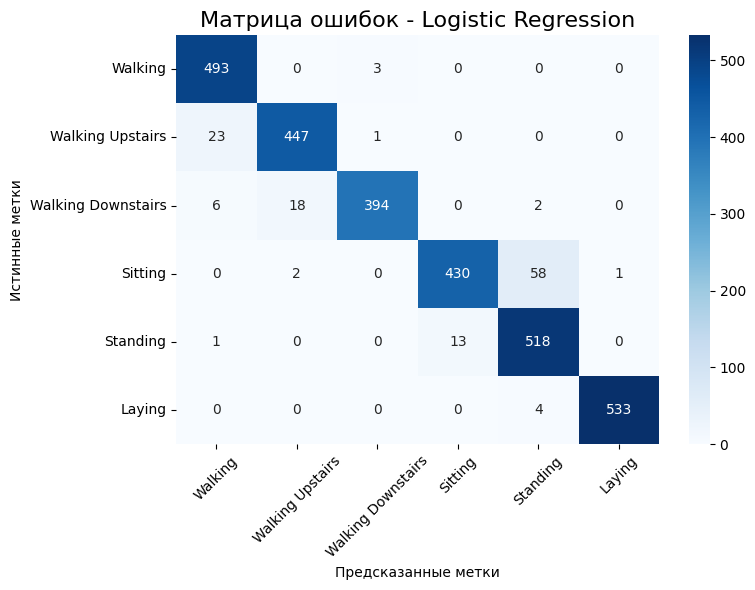

In [14]:
# %% [markdown]
# ## Матрица ошибок для лучшей модели

# %%
# Выбор лучшей модели
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

# Переобучение лучшей модели
best_model.fit(train_X, train_y)
yhat_best = best_model.predict(test_X)

# Матрица ошибок
cm = confusion_matrix(test_y, yhat_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Матрица ошибок - {best_model_name}', fontsize=16)
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# ## Детальный анализ лучшей модели

# %%
print(f"\nЛучшая модель: {best_model_name}")
print(f"Точность: {results[best_model_name]:.4f}")

print("\nДетальный отчет для лучшей модели:")
print(classification_report(test_y, yhat_best, target_names=target_names))


Лучшая модель: Logistic Regression
Точность: 0.9552

Детальный отчет для лучшей модели:
                    precision    recall  f1-score   support

           Walking       0.94      0.99      0.97       496
  Walking Upstairs       0.96      0.95      0.95       471
Walking Downstairs       0.99      0.94      0.96       420
           Sitting       0.97      0.88      0.92       491
          Standing       0.89      0.97      0.93       532
            Laying       1.00      0.99      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.95      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



In [16]:
# ## Кросс-валидация для лучшей модели

# %%
# Проверка устойчивости результатов с помощью кросс-валидации
cv_scores = cross_val_score(best_model, train_X, train_y, cv=5)
print(f"\nРезультаты кросс-валидации (5-fold) для {best_model_name}:")
print(f"Средняя точность: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Все оценки: {cv_scores}")

# %% [markdown]
# ## Обоснование выбора моделей

# %%
# Выводы и обоснование
print("\n" + "="*50)
print("ОБОСНОВАНИЕ ВЫБОРА МОДЕЛЕЙ")
print("="*50)

print("""
1. Random Forest:
   - Устойчив к переобучению
   - Хорошо работает с большим количеством признаков
   - Может определять важность признаков

2. SVM (Support Vector Machine):
   - Эффективен в задачах классификации
   - Хорошо работает с нелинейными данными (с ядром RBF)
   - Устойчив к шуму в данных

3. Logistic Regression:
   - Простая и интерпретируемая модель
   - Быстрое обучение и предсказание
   - Хорошая базовая модель для сравнения

4. K-Nearest Neighbors:
   - Непараметрический метод
   - Простота реализации
   - Хорошо работает, когда данные имеют кластерную структуру

5. Decision Tree:
   - Полная интерпретируемость
   - Простота понимания
   - Быстрое предсказание
""")

print(f"\nРЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
for name, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {accuracy:.4f}")


Результаты кросс-валидации (5-fold) для Logistic Regression:
Средняя точность: 0.9350 (+/- 0.0490)
Все оценки: [0.92114208 0.8946295  0.94421769 0.95102041 0.96394558]

ОБОСНОВАНИЕ ВЫБОРА МОДЕЛЕЙ

1. Random Forest:
   - Устойчив к переобучению
   - Хорошо работает с большим количеством признаков
   - Может определять важность признаков

2. SVM (Support Vector Machine):
   - Эффективен в задачах классификации
   - Хорошо работает с нелинейными данными (с ядром RBF)
   - Устойчив к шуму в данных

3. Logistic Regression:
   - Простая и интерпретируемая модель
   - Быстрое обучение и предсказание
   - Хорошая базовая модель для сравнения

4. K-Nearest Neighbors:
   - Непараметрический метод
   - Простота реализации
   - Хорошо работает, когда данные имеют кластерную структуру

5. Decision Tree:
   - Полная интерпретируемость
   - Простота понимания
   - Быстрое предсказание


РЕЗУЛЬТАТЫ СРАВНЕНИЯ:
Logistic Regression: 0.9552
SVM: 0.9522
Random Forest: 0.9260
K-Nearest Neighbors: 0.8802
De

Опишите вашу мотивацию по выбору модели. Какие гиперпараметры есть у выбранной вами модели? За что они отвечают? На что влияют?

## Обучение модели

Обучите модель, используя признаки из обучающего набора (`train_X`) и метки в качестве базовой истины (`train_y`).

In [ ]:
model.fit(train_X, train_y)

## Оценка модели
Используйте обученную модель для прогнозирования активности движения, используя признаки из тестового набора (`test_X`). Прогнозы сохраните в списке `yhat`.

In [ ]:
yhat = model.predict(test_X)
yhat

In [ ]:
from sklearn.metrics import classification_report
target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

print(classification_report(test_y, yhat, target_names=target_names))

In [ ]:
#Результаты сравнения






## Задание


Выведите отчет о классификации, сравнив предсказания (`yhat`) с базовой истиной (`test_y`).

В чем разница между показателями `precision` и `recall`? Что такое показатель `F1`?

Используйте вариации нескольких моделей с разными гиперпараметрами. Сравните полученный результат (визуализируйте полученный результат).

Что такое гиперпараметры модели машинного обучения (МО)?

Опишите влияние гиперпараметров в выбранных вами моделях МО.